In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import time

#### Data Preparation

In [2]:
# Load the datasets
inf = pd.read_excel('Inflation rates from upto march.xlsx')
macro = pd.read_csv('macro_data_63_months.txt')
sentiment_score = pd.read_csv('finBERT Sentiment-Inflation.csv')

# Turning each month into datetime type
inf['month'] = pd.to_datetime(inf['month']).dt.to_period('M').dt.to_timestamp()
macro['month'] = pd.to_datetime(macro['month']).dt.to_period('M').dt.to_timestamp()
sentiment_score['date'] = pd.to_datetime(sentiment_score['date']).dt.to_period('M').dt.to_timestamp()

# Aligning the sentiment score monthly data format to the first two data

# Inner merge the two data
df = pd.merge(inf, macro, on= 'month', how = 'inner')
# Merging the sentiment
df_final = pd.merge(df, sentiment_score.drop('inflation', axis =1), left_on = 'month', right_on = 'date', how = 'right').drop('date', axis = 1)
df_final

,month,inflation,usd_php,oil_brent,sentiment
0,2021-01-01,3.7,48.100000,55.000000,-0.096034
1,2021-02-01,4.2,48.318182,56.818182,0.019575
2,2021-03-01,4.1,48.536364,58.636364,-0.041243
3,2021-04-01,4.1,48.754545,60.454545,0.023667
4,2021-05-01,4.1,48.972727,62.272727,-0.017046
...,...,...,...,...,...
60,2026-01-01,2.0,59.160000,64.500000,-0.028967
61,2026-02-01,2.4,58.280000,66.960000,-0.000079
62,2026-03-01,4.1,59.410000,102.860000,0.023276
63,NaT,NaN,NaN,NaN,0.013479


#### Visualizing the relationship of 4 Variables

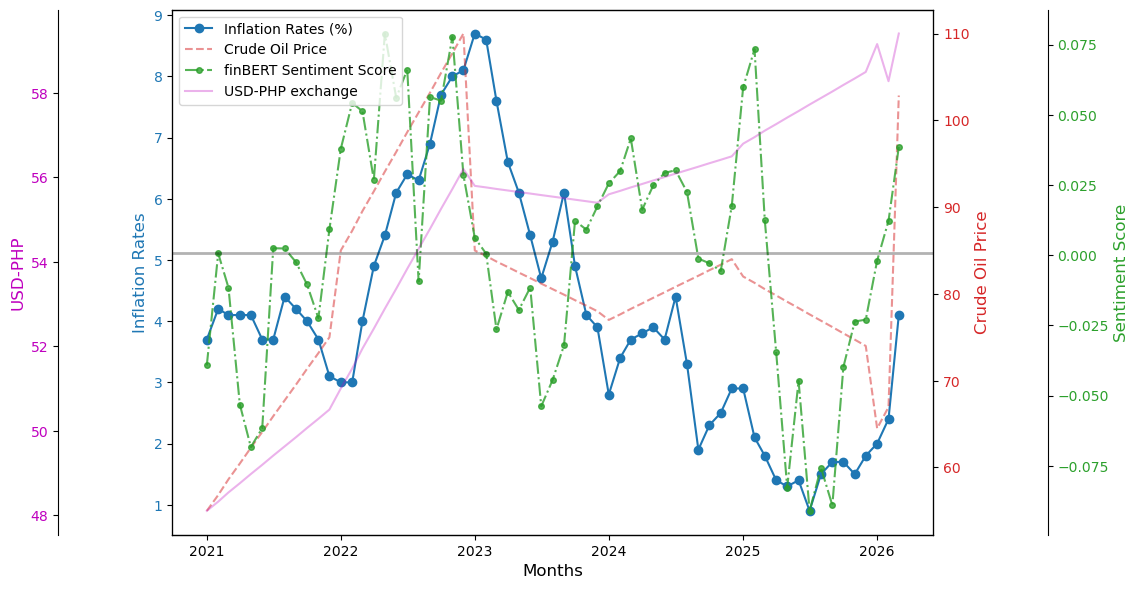

In [3]:
fig, ax1 = plt.subplots(figsize = (12,6))

ax1.plot(df_final['month'], 
         df_final['inflation'], 
         color = 'tab:blue', 
         marker = 'o', 
         label = 'Inflation Rates (%)')
ax1.set_xlabel('Months', 
               fontsize = 12)
ax1.set_ylabel('Inflation Rates', 
               color = 'tab:blue', 
               fontsize =12)
ax1.tick_params('y', 
                labelcolor ='tab:blue')

ax2 = ax1.twinx()

ax2.plot(df_final['month'], 
         df_final['oil_brent'], 
         color = 'tab:red', 
         linestyle = '--',
         alpha = 0.5,
         label = 'Crude Oil Price')
ax2.set_ylabel('Crude Oil Price', color = 'tab:red', fontsize = 12)
ax2.tick_params('y', labelcolor = 'tab:red')

ax3 = ax1.twinx()
# Moving the scale slight to right
ax3.spines['right'].set_position(('axes', 1.15))

ax3.plot(df_final['month'],
         df_final['sentiment'].rolling(window = 3).mean().shift(-2), 
         color = 'tab:green', 
         linestyle = '-.',
         alpha = 0.8,
         marker = 'o',
         markersize = 4,
         label = 'finBERT Sentiment Score')
ax3.set_ylabel('Sentiment Score', 
               color = 'tab:green', 
               fontsize = 12)
ax3.tick_params('y', 
                labelcolor = 'tab:green')
ax3.axhline((df_final['sentiment'].rolling(window = 3).mean().shift(2)).mean(), 
             color = 'black', 
             linewidth = 2,
             alpha = 0.3)

ax4 = ax1.twinx()

ax4.yaxis.set_label_position('left')
ax4.yaxis.set_ticks_position('left')
ax4.spines['left'].set_position(('axes', -0.15))
ax4.plot(df_final['month'],
         df_final['usd_php'],
         color = 'm',
         alpha = 0.3,
         label = 'USD-PHP exchange')
ax4.set_ylabel('USD-PHP',
               color = 'm',
               fontsize = 12)
ax4.tick_params('y', labelcolor = 'm')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()

ax4.legend(lines+lines2+lines3+lines4,
           labels+labels2+labels3+labels4,
           loc = 'upper left')

fig.tight_layout()
plt.show()

#### Check correlation of data

In [4]:
inf_sent_corr = df_final['inflation'].corr(df_final['sentiment'].rolling(window = 3).mean().shift(-2))
inf_oil_Corr = df_final['inflation'].corr(df_final['oil_brent'])
inf_USD_Php_Corr = df_final['inflation'].corr(df_final['usd_php'].pct_change())
print(f'Inflation - Sentiment Corr: {inf_sent_corr}')
print(f'Inflatoin - Oil Corr: {inf_oil_Corr}')
print(f'Inflation - USD/PhP Corr: {inf_USD_Php_Corr}')

df_final['usd_php_pct_change'] = df_final['usd_php'].pct_change()
for lag in [1, 2, 3, 4]:
    lagged_corr = df_final['inflation'].corr(df_final['usd_php_pct_change'].shift(lag))
    print(f"USD/PHP % Change (Lag {lag}) vs Inflation Corr: {lagged_corr:.4f}")

Inflation - Sentiment Corr: 0.34750761144258835
Inflatoin - Oil Corr: 0.4954812059068101
Inflation - USD/PhP Corr: 0.0581293610637927
USD/PHP % Change (Lag 1) vs Inflation Corr: 0.1148
USD/PHP % Change (Lag 2) vs Inflation Corr: 0.3083
USD/PHP % Change (Lag 3) vs Inflation Corr: 0.4272
USD/PHP % Change (Lag 4) vs Inflation Corr: 0.4963


C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_16140\3113458933.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inf_USD_Php_Corr = df_final['inflation'].corr(df_final['usd_php'].pct_change())
C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_16140\3113458933.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_final['usd_php_pct_change'] = df_final['usd_php'].pct_change()


#### Building ARIMA/SARIMA model

In [5]:
# Separating Inflation dataset

# Splitting the data to train-test sets 
train_size = int(len(df_final)*.8)
inf_train = df_final[0:train_size]
inf_test = df_final[train_size:int(len(df_final))]

# Check the data 
print(f'Trainig on: {inf_train.index.min()} to {inf_train.index.max()}')
print(f'Testing on: {inf_test.index.min()} to {inf_test.index.max()}')

Trainig on: 0 to 51
Testing on: 52 to 64


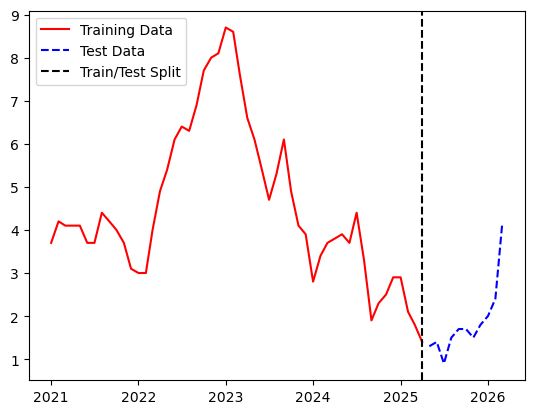

In [6]:
fig = plt.plot(figsize = (30,15))

plt.plot(inf_train['month'], inf_train['inflation'], color  = 'red', label = 'Training Data')
plt.plot(inf_test['month'], inf_test['inflation'], color = 'blue', linestyle = '--', label = 'Test Data')

plt.axvline(inf_train['month'].max(), color = 'black', linestyle = '--', label = 'Train/Test Split')

plt.legend()
plt.show()

### Checking Assumptions for building ARIMA/SARIMA model

##### Stationarity Check

In [7]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)[1]

    if result > 0.05:
        print(f'ADF: {result}, differencing is needed')
    else:
        print(f'ADF: {result}, no differencing needed. Data is stationary')

adf_test(inf_train['inflation'].dropna())

ADF: 0.3546636275136579, differencing is needed


##### Seasonality Check

In [8]:
from pmdarima.arima.utils import nsdiffs

def n_diffs(series):
    result = nsdiffs(series, m = 12, test = 'ocsb')
    print(f'Suggested Seasonal Differencing: {result}')

n_diffs(inf_train['inflation'].dropna())

Suggested Seasonal Differencing: 0


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


##### Seasonal and Trend Decomposition

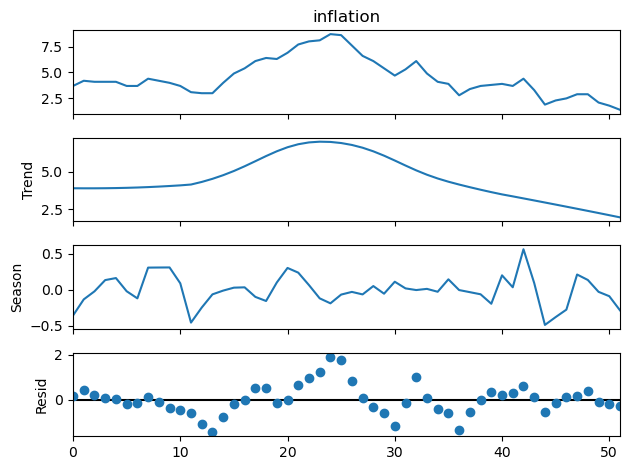

In [9]:
from statsmodels.tsa.seasonal import STL

res = STL(inf_train['inflation'].dropna(), period = 12).fit()
res.plot()
plt.show()

##### ACF/PCF plotting to further check seasonality

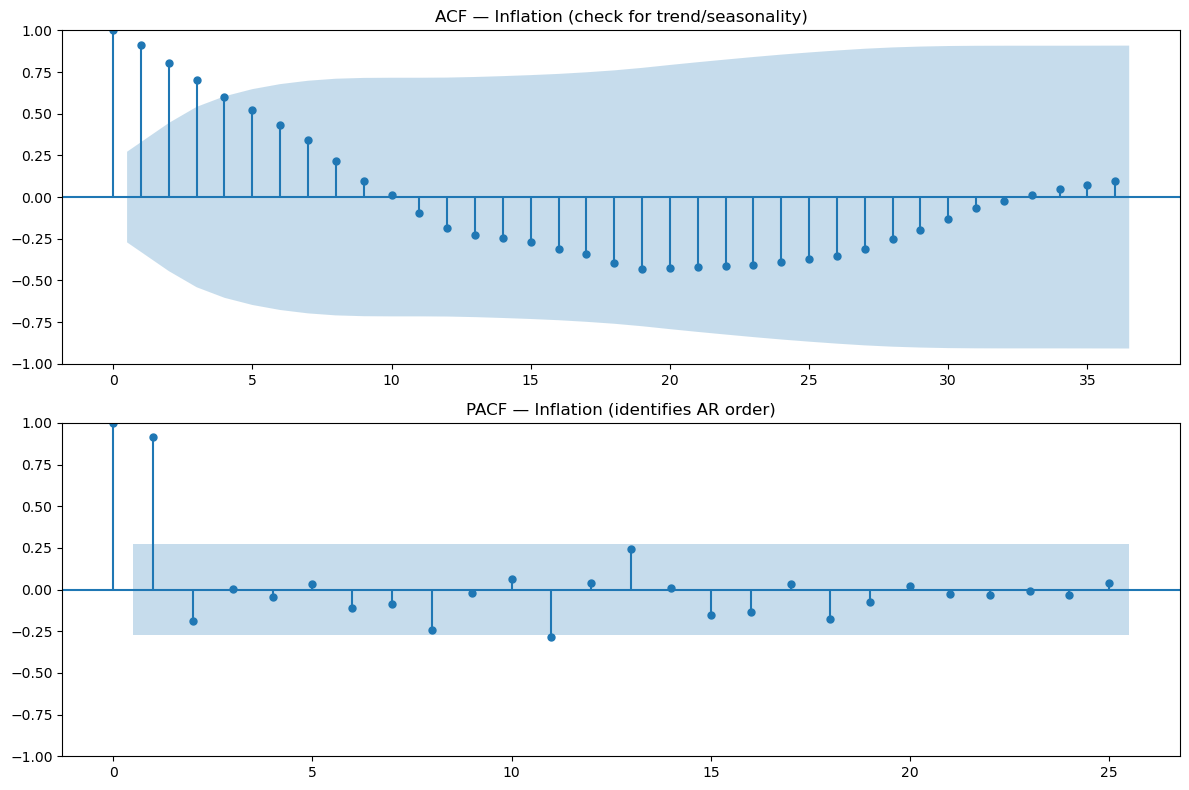

In [10]:
import statsmodels.api as sm

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF
sm.graphics.tsa.plot_acf(
    inf_train['inflation'].dropna(),
    lags=36,
    alpha=0.05,
    ax=axes[0],
    title='ACF — Inflation (check for trend/seasonality)'
)

# PACF — run this alongside ACF always
sm.graphics.tsa.plot_pacf(
    inf_train['inflation'].dropna(),
    lags=25,
    alpha=0.05,
    method='ywm',
    ax=axes[1],
    title='PACF — Inflation (identifies AR order)'
)

plt.tight_layout()
plt.show()




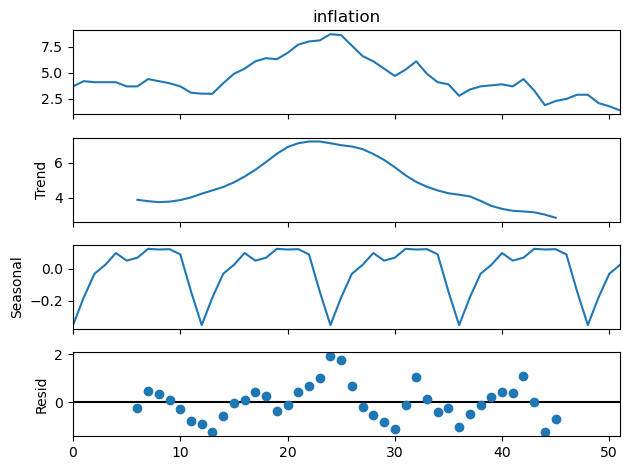

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(inf_train['inflation'].dropna(),
                            model = 'additive',
                            period = 12)

decomp.plot()
plt.tight_layout()
plt.show()

# This shows that nsdiffs prove that no Seasonal Differencing needed
# While other tests like ACF and PACF and Seasonal Decomposition shows that there is a weak seasonality.
# Auto ARIMA will be used and make sure that Seasonal Differencing is not included

In [15]:
from pmdarima import auto_arima
arima_model = auto_arima(
    inf_train['inflation'].dropna(),
    seasonal=True,
    m=12,
    d=1,          # force differencing since ADF confirmed it
    D=0,          # no seasonal differencing per nsdiffs
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2,
    stepwise=False,   # exhaustive search instead of stepwise
    information_criterion='aic',
    trace=True
)

orders = arima_model.order

C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=96.867, Time=0.03 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.45 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=81.238, Time=0.13 sec


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.24 sec


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(3,1,1)(0,0,0)[12] intercept   : AIC=88.155, Time=0.13 sec


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(3,1,1)(1,0,0)[12] intercept   : AIC=74.438, Time=0.19 sec


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,2)(0,0,0)[12] intercept   : AIC=89.470, Time=0.23 sec

Best model:  ARIMA(1,1,1)(1,0,0)[12] intercept
Total fit time: 25.918 seconds


In [14]:
train_residuals = arima_model.resid()
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   52
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 12)   Log Likelihood                 -31.844
Date:                             Sun, 24 May 2026   AIC                             73.688
Time:                                     22:55:28   BIC                             83.347
Sample:                                          0   HQIC                            77.379
                                              - 52                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0642      0.153     -0.421      0.674      -0.363       0.235
ar.L1         -0.4890      0.194     -2.514      0.012      -0.870      -0.108
ma.L1          0.9682      0.124      7.781      0.000       0.724       1.212
ar.S.L12      -0.5216      0.143     -3.659      0.000      -0.801      -0.242
sigma2         0.1810      0.041      4.416      0.000       0.101       0.261
===================================================================================
Ljung-Box (L1) (Q):                   0.11   Jarque-Bera (JB):                 0.05
Prob(Q):                              0.74   Prob(JB):                         0.97
Heteroskedasticity (H):               1.20   Skew:                            -0.03
Prob(H) (two-sided):                  0.72   Kurtosis:                         2.85
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
inf_train = inf_train.set_index('month')

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   52
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 12)   Log Likelihood                 -31.844
Date:                             Sun, 24 May 2026   AIC                             73.688
Time:                                     23:12:42   BIC                             83.347
Sample:                                          0   HQIC                            77.379
                                              - 52                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0642      0.153     -0.421      0.674      -0.363       0.235
ar.L1         -0.4890      

C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


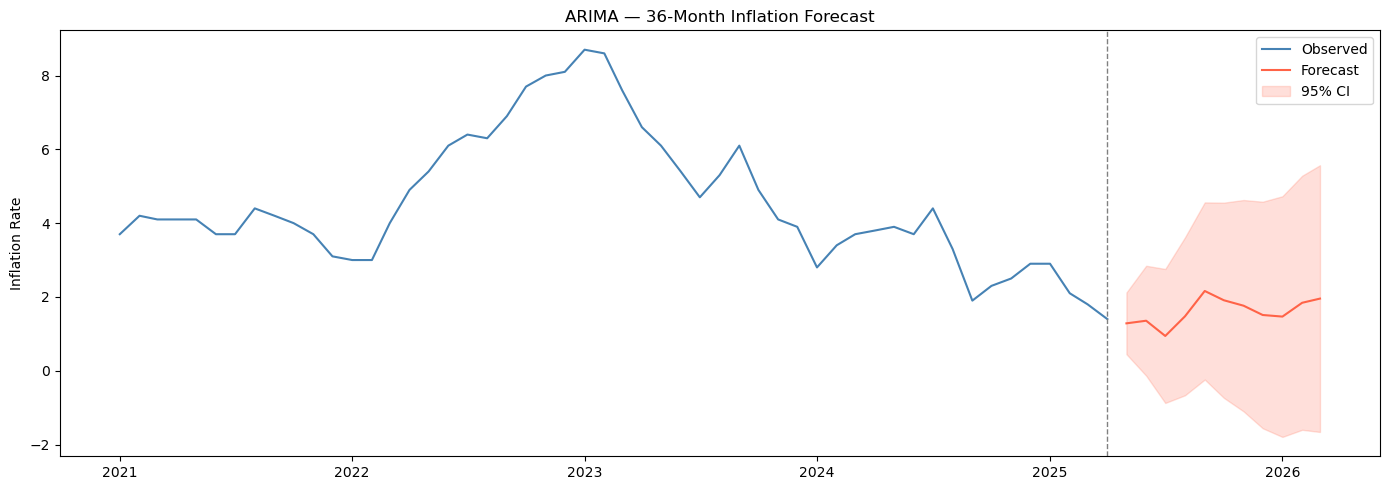

            forecast  lower_ci  upper_ci
2025-05-01  1.284555  0.449224  2.119886
2025-06-01  1.355605 -0.133528  2.844738
2025-07-01  0.942543 -0.872909  2.757995
2025-08-01  1.475526 -0.664714  3.615766
2025-09-01  2.161477 -0.238980  4.561934
2025-10-01  1.910277 -0.734280  4.554834
2025-11-01  1.762556 -1.101118  4.626231
2025-12-01  1.510927 -1.558201  4.580056
2026-01-01  1.467735 -1.793033  4.728503
2026-02-01  1.841915 -1.600255  5.284085
2026-03-01  1.955251 -1.659034  5.569535


In [45]:
from pmdarima import auto_arima
import matplotlib.pyplot as plt
import pandas as pd


print(arima_model.summary())



# --- Step 2: Forecast 36 months ---
n_forecast = 11
forecast, conf_int = arima_model.predict(n_periods=n_forecast, return_conf_int=True)

last_date = inf_train['inflation'].dropna().index[-1]
forecast_index = pd.date_range(start=last_date, periods=n_forecast + 1, freq='MS')[1:]

forecast_df = pd.DataFrame({
    'forecast':   forecast.values,
    'lower_ci':   conf_int[:, 0],
    'upper_ci':   conf_int[:, 1]
}, index=forecast_index)

# --- Step 3: Plot ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(inf_train['inflation'].dropna(), label='Observed', color='steelblue')
ax.plot(forecast_df['forecast'], label='Forecast', color='tomato')
ax.fill_between(forecast_df.index,
                forecast_df['lower_ci'],
                forecast_df['upper_ci'],
                alpha=0.2, color='tomato', label='95% CI')

ax.axvline(x=last_date, color='gray', linestyle='--', linewidth=1)
ax.set_title('ARIMA — 36-Month Inflation Forecast')
ax.set_ylabel('Inflation Rate')
ax.legend()
plt.tight_layout()
plt.show()

print(forecast_df)

In [41]:
len(inf_test['inflation'].dropna())

11

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

def err_metrics(y_true, y_pred):
    # 1. Mean Squared Error (MSE)
    mse = mean_squared_error(y_true, y_pred)
    
    # 2. Root Mean Squared Error (RMSE)
    # In newer versions of sklearn, you can use squared=False
    rmse = root_mean_squared_error(y_true, y_pred)
    
    # 3. Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")

err_metrics(inf_test['inflation'].dropna(), forecast.values[0:11])

MSE: 0.5099099232079017
RMSE: 0.714079773700321
MAE: 0.41684898144454774


In [39]:
forecast.values[0:13]

array([1.28455503, 1.35560514, 0.94254298, 1.47552602, 2.16147684,
       1.9102769 , 1.76255618, 1.51092734, 1.46773494, 1.84191501,
       1.95525063, 2.12076901, 2.13785403])